# 05 Business Output

**Goal:** Train the deployment model on all labelled data, explain it, and generate the priority customer list for the retention team.

Covers: deployment model fit, SHAP feature attributions, priority-list scoring, risk-tier assignment, risk-band profiling, and the exported call list.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pickle
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(transform_output='pandas')
from sklearn.pipeline import Pipeline as _Pipeline
from sklearn.inspection import permutation_importance

from src.config import SEED
from src.pipelines import ALL_FEATURES, make_boost_pipeline
from src.evaluation import calibrate_isotonic
from src.reporting import plot_feature_importance, plot_risk_band_profiles


## 1. Load Artifacts

In [2]:
master = pd.read_parquet('artifacts/master.parquet', engine='pyarrow')
master['datevalue'] = pd.to_datetime(master['datevalue'])

with open('artifacts/data_end.txt') as f:
    DATA_END = pd.Timestamp(f.read().strip())

with open('artifacts/window_results.pkl', 'rb') as f:
    _saved = pickle.load(f)
window_results = _saved['window_results']
obs_months     = _saved['obs_months']

print(f'master: {master.shape}  |  DATA_END: {DATA_END.date()}')

all_y     = np.concatenate([r['y_test']     for r in window_results])
boost_all = np.concatenate([r['boost_prob'] for r in window_results])

master: (3292482, 69)  |  DATA_END: 2024-05-01


## 2. Deployment Model

Fit on all rows up to `DATA_END` — the right-censoring cutoff beyond which churn labels are unreliable.
`SCORE_MONTH` is set to the latest snapshot in the data (`master['datevalue'].max()`), which sits beyond the label window and is therefore genuinely out-of-sample.

In [3]:
SCORE_MONTH = master['datevalue'].max()
df_final = master[master['datevalue'] <= DATA_END].copy()
X_final, y_final = df_final[ALL_FEATURES], df_final['label']

final_boost = make_boost_pipeline().fit(X_final, y_final)
print(f'Deployment model fitted on {len(X_final):,} rows, '
      f'{df_final["datevalue"].nunique()} months  |  scoring month: {SCORE_MONTH.date()}')

Deployment model fitted on 2,982,846 rows, 22 months  |  scoring month: 2024-09-01


## 3. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) explains each prediction by attributing a contribution to every feature. Computed on the **held-out scoring month** (`SCORE_MONTH`) — data the deployment model never saw during training.

The beeswarm plot shows both **direction** (left = lowers churn risk, right = raises it) and **magnitude** simultaneously. Each dot is one customer; colour encodes feature value (red = high, blue = low).

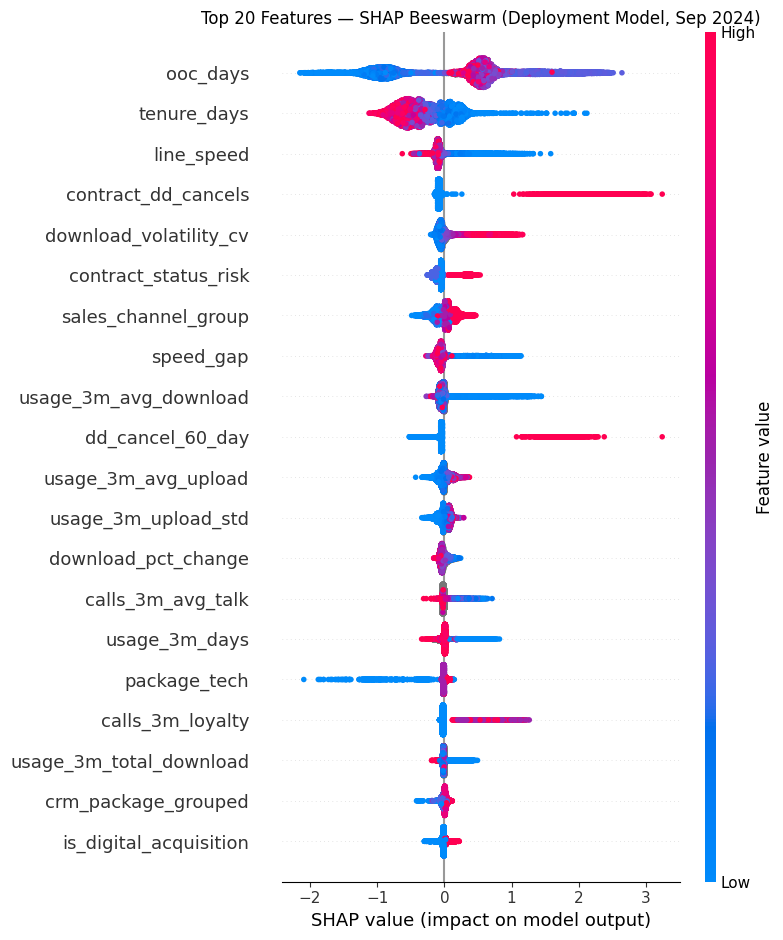

In [4]:
imp_te = master[master['datevalue'] == SCORE_MONTH]
_pre   = _Pipeline(final_boost.steps[:-1])
rng    = np.random.default_rng(SEED)
te_idx = rng.choice(len(imp_te), size=min(20_000, len(imp_te)), replace=False)
X_shap = _pre.transform(imp_te[ALL_FEATURES].iloc[te_idx])

explainer = shap.TreeExplainer(final_boost.named_steps['model'])
shap_vals = explainer.shap_values(X_shap)

if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]
elif getattr(shap_vals, 'ndim', 2) == 3:
    shap_vals = shap_vals[..., 1]

shap.summary_plot(shap_vals, X_shap, max_display=20, show=False)
plt.title(f'Top 20 Features — SHAP Beeswarm (Deployment Model, {SCORE_MONTH.strftime("%b %Y")})')
plt.tight_layout()
plt.show()

 **Reading the chart.** `ooc_days` and `tenure_days` dominate — high OOC days (red, far right) push strongly toward churn, while long tenure (red, far left) pulls it down. Below them, payment stress (`contract_dd_cancels`, `dd_cancel_60_day`) and the speed signal (`line_speed`, `speed_gap` — customers sold a headline speed they don't actually receive) sit on the high-risk side. Unlike the LR coefficients, SHAP captures the non-linear threshold effect: `ooc_days` risk jumps around end-of-contract rather than rising linearly.


## 4. Priority Customer List

Score all customers in the **most recent snapshot** (`SCORE_MONTH`).

**Two scores per customer:**
- `churn_score`: raw model output — use for **ranking and prioritisation** (reliable, monotone; do not interpret as a probability)
- `calibrated_prob`: isotonic-calibrated probability — use for **business communication and expected-value calculations** (scaled to match the ~12% observed churn rate)

Risk tiers are assigned by **score percentile** rather than raw-score cutoffs so they align with operational channel capacity. The min-cost analysis in notebook 04 recommends a broad-contact strategy: because a missed churner costs far more than an unnecessary call, the cost-optimal threshold deliberately flags a large share of the base. The tier system translates this into a priority order: P1/P2 take the top 10% through expensive phone channels, P3 reaches the next 20% via scalable email/SMS, and P4 is a watch list below the current channel-capacity cutoff — capacity, not cost, is the binding constraint on how far down the ranked list active outreach extends.

**Note:** The deployment model is trained on all months up to `DATA_END` (the right-censoring cutoff); months between `DATA_END` and `SCORE_MONTH` are excluded from training because their churn labels are not yet fully observed. The scored customers are therefore genuinely out-of-sample. `iso_cal` was fit on the out-of-sample CV scores from the rolling windows, so `calibrated_prob` values are comparable to those reported in notebook 04.

In [5]:
iso_cal, _ = calibrate_isotonic(all_y, boost_all)

df_score = master[master['datevalue'] == SCORE_MONTH].copy()
raw_score = final_boost.predict_proba(df_score[ALL_FEATURES])[:, 1]
df_score['churn_score']     = raw_score
df_score['calibrated_prob'] = iso_cal.predict(raw_score)

pct = df_score['churn_score'].rank(pct=True)
df_score['risk_tier'] = pd.cut(
    pct, bins=[0, 0.70, 0.90, 0.97, 1.0],
    labels=['P4 Monitor', 'P3 Email/SMS', 'P2 Outbound', 'P1 Call first'],
    include_lowest=True)

print(f'Customers scored for {SCORE_MONTH.date()}: {len(df_score):,}')
print(f'Raw score range    : {raw_score.min():.3f} - {raw_score.max():.3f}')
print(f'Calibrated prob    : {df_score["calibrated_prob"].min():.3f} - {df_score["calibrated_prob"].max():.3f}')
print('\nRisk tier breakdown:')
tier_tbl = (
    df_score.groupby('risk_tier', observed=True)
    .agg(customers=('churn_score','size'), mean_calibrated_prob=('calibrated_prob','mean'))
    .reindex(['P1 Call first','P2 Outbound','P3 Email/SMS','P4 Monitor'])
)
print(tier_tbl.to_string())

Customers scored for 2024-09-01: 71,635
Raw score range    : 0.003 - 0.995
Calibrated prob    : 0.000 - 1.000

Risk tier breakdown:
               customers  mean_calibrated_prob
risk_tier                                     
P1 Call first       2150              0.830151
P2 Outbound         5014              0.461731
P3 Email/SMS       14327              0.121944
P4 Monitor         50144              0.027821


## 5. Risk Band Diagnostic

Median feature values by risk tier — shows **why** each group is where it is.
P1 (highest risk) should show: high `ooc_days`, high `calls_3m_loyalty`,
low `tenure_days` (or very high — U-shaped), and more DD cancellations.

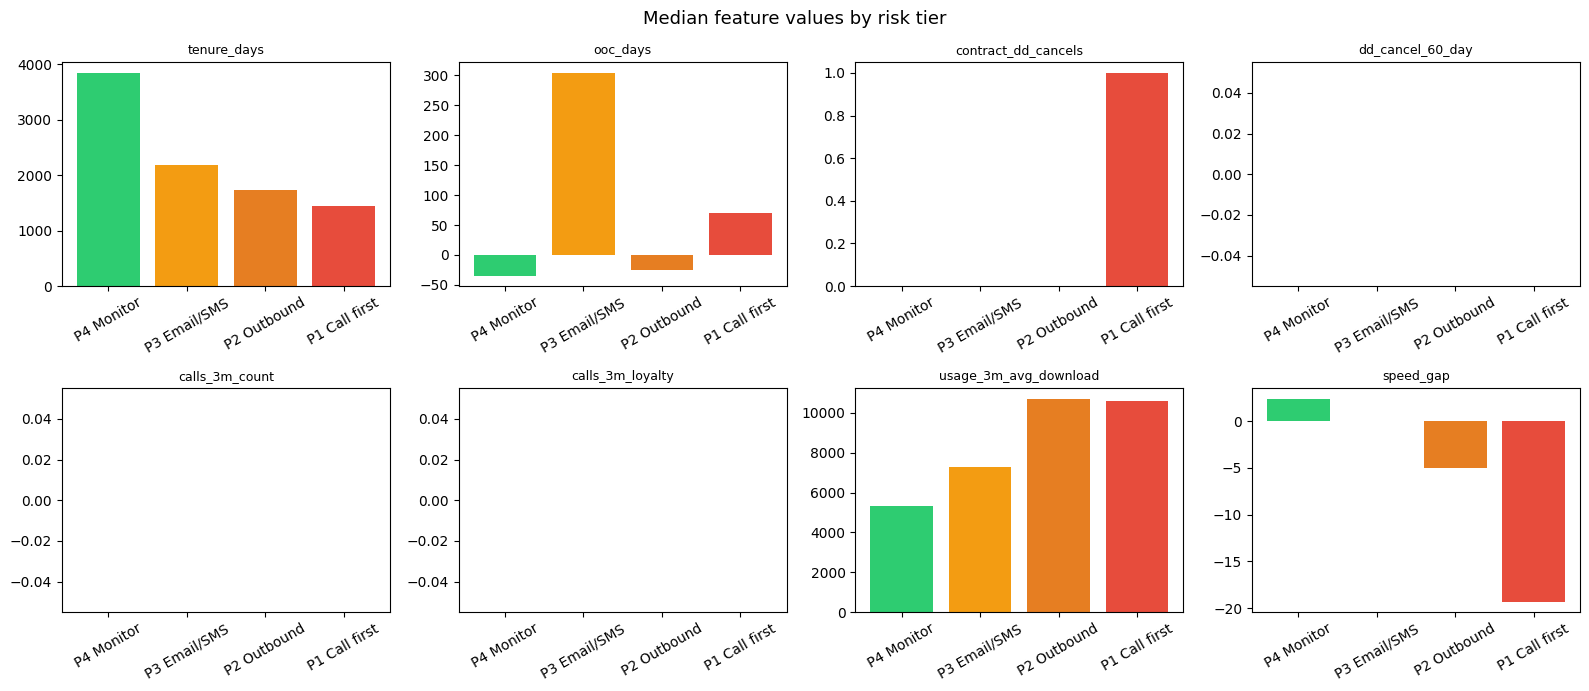

In [6]:
plot_risk_band_profiles(df_score)

> **The sanity check.** Moving from P4 up to P1: median `ooc_days` climbs, DD cancellations climb, and tenure falls. The tier profiles match exactly the churner signature that EDA and SHAP both pointed to. Internal consistency across the ranking model, feature importance, and segment profiles is the final validation before handing over the list.

## 6. Export Priority List

In [7]:
top_customers = (
    df_score[['unique_customer_identifier', 'churn_score', 'calibrated_prob',
               'risk_tier', 'contract_status', 'tenure_days', 'ooc_days',
               'technology', 'calls_3m_loyalty', 'calls_3m_count']]
    .sort_values('churn_score', ascending=False)
    .head(1000)
)
top_customers.to_csv('top_churn_risk_customers.csv', index=False)
print(f'Top 1,000 at-risk customers saved to top_churn_risk_customers.csv')
top_customers.head(10)

Top 1,000 at-risk customers saved to top_churn_risk_customers.csv


,unique_customer_identifier,churn_score,calibrated_prob,risk_tier,contract_status,tenure_days,ooc_days,technology,calls_3m_loyalty,calls_3m_count
2638152,597f3c5bff5f198e95c4334349e13429ff9d838a86bab4...,0.995367,1.000000,P1 Call first,06 OOC,2025,382.0,FTTC,1.0,1.0
2392442,74618c47cd2be809d6627708565539651fc7fab1f44b41...,0.993935,0.976744,P1 Call first,06 OOC,4336,227.0,FTTC,1.0,1.0
1147261,f55a28b22ea736a88ba72ceaa60747d11cbbbf5c4878c3...,0.993692,0.976744,P1 Call first,05 Newly OOC,786,56.0,FTTC,1.0,1.0
1256117,cc4d0a72bc3422537cbd633a725d7b12d21f8e8c03f808...,0.993674,0.976744,P1 Call first,06 OOC,5307,464.0,FTTC,0.0,0.0
845518,aaaafe3321971744e3371b9273dcd7faeb2057147a894d...,0.993492,0.976744,P1 Call first,05 Newly OOC,226,23.0,MPF,1.0,1.0
2717996,8a90ffb7565870a38dbc05bbbb15cf8afd2ba713e8e4a9...,0.993422,0.976744,P1 Call first,06 OOC,6225,1742.0,FTTC,1.0,1.0
2084699,66f25afd2ad83732738a97928a79da020d5b995754629a...,0.993393,0.976744,P1 Call first,06 OOC,2610,2246.0,FTTC,0.0,0.0
1167256,a6e72071ecbd996ff036b6da1a48999336ae4f872c5ebe...,0.993385,0.976744,P1 Call first,06 OOC,4827,205.0,FTTC,0.0,0.0
3196611,9e09396ed1a356fc21964821c1def895541cb2cb284791...,0.993291,0.976744,P1 Call first,06 OOC,418,721.0,FTTC,0.0,0.0
1894947,7acf51680908c4f8b48ea908b111f64a2f7a3548a4907c...,0.993277,0.976744,P1 Call first,05 Newly OOC,6260,9.0,FTTC,1.0,1.0


> **What's in the CSV.** Each row is one at-risk customer with: unique ID, raw `churn_score` (for ordering), `calibrated_prob` (for quoting), risk tier, and key context fields — contract status, tenure, OOC days, recent loyalty calls. An agent can pick up the phone with a reason in hand rather than a bare customer ID.